# T QML Power Spectrum Analysis

This notebook provides a step-by-step analysis of QML power spectrum estimation for T (Temperature) data.

## 1. Import Required Libraries

In [1]:
import os
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import yaml
from mpi4py import MPI

# Import cosmocore modules
from cosmocore import (
    InputParams,
    do_derivative_step,
    matrix_mult,
    matrix_trace,
    read_maps,
)

# Import qube modules
from qube import Spectra

# Set up plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)

print("All imports successful!")
print(f"MPI size: {MPI.COMM_WORLD.Get_size()}, rank: {MPI.COMM_WORLD.Get_rank()}")

All imports successful!
MPI size: 1, rank: 0


In [2]:
def configure_plt():
    plt.rc("axes", labelsize=20, linewidth=1.5)
    plt.rc("xtick", direction="in", labelsize=15, top=True)
    plt.rc("ytick", direction="in", labelsize=15, right=True)

    plt.rc("xtick.major", width=1.1, size=5)
    plt.rc("ytick.major", width=1.1, size=5)

    plt.rc("xtick.minor", width=1.1, size=3)
    plt.rc("ytick.minor", width=1.1, size=3)

    plt.rc("lines", linewidth=2)
    plt.rc("legend", frameon=False, fontsize=15)
    plt.rc("figure", dpi=100, autolayout=True, figsize=[10, 7])
    plt.rc("savefig", dpi=300, bbox="tight")


configure_plt()

## 2. Setup Test Parameters and Configuration

In [3]:
QUBE_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))


def resolve_config(config_rel, overrides=None):
    """Anchor YAML paths to qube root so the notebook runs from any cwd."""
    full_path = os.path.join(QUBE_ROOT, config_rel)
    with open(full_path) as f:
        config = yaml.safe_load(f)
    for key, value in config.items():
        if isinstance(value, str):
            clean = value
            while clean.startswith("../"):
                clean = clean[3:]
            if clean.startswith("tests/") or clean.startswith("scripts/"):
                config[key] = os.path.join(QUBE_ROOT, clean)
    if overrides:
        config.update(overrides)
    tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".yaml", delete=False)
    yaml.dump(config, tmp, default_flow_style=False)
    tmp.close()
    return tmp.name

In [4]:
# Set up test configuration paths
local_path = os.path.abspath(os.getcwd())
fields = "T"  # Use TQU configuration for debugging
nside = 4
param_file = resolve_config(f"tests/data/nside{nside}/{fields}/config.yaml")

print(f"Local path: {local_path}")
print(f"Parameter file: {param_file}")
print(f"Parameter file exists: {os.path.exists(param_file)}")

# Load parameters
params = InputParams.read_parameter_file(param_file)

# Display key parameters
print("\n=== Key Parameters ===")
print(f"nside: {params.nside}")
print(f"spins: {params.spins}")
print(f"labels: {getattr(params, 'labels', 'Not specified')}")
print(f"physical_labels: {getattr(params, 'physical_labels', 'Not specified')}")
print(f"nspectra: {params.nspectra}")
print(f"lmax: {params.lmax}")
print(f"nsims: {params.nsims}")
print(f"do_cross: {params.do_cross}")
print(f"calibration: {params.calibration}")

Local path: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.qube/notebooks
Parameter file: /tmp/tmprts8epts.yaml
Parameter file exists: True

=== Key Parameters ===
nside: 4
spins: [0]
labels: ['T']
physical_labels: ['T']
nspectra: 1
lmax: 8
nsims: 50
do_cross: False
calibration: 1.0


## 3. Initialize Spectra Instance

In [5]:
# Initialize Spectra instance
print("Creating Spectra instance...")
spectra = Spectra(param_file)

# Display MPI and basic info
print(f"MPI rank: {spectra.rank}")
print(f"MPI size: {spectra.size}")
print(f"Parameters loaded: {spectra.params is not None}")
print(f"Fisher instance created: {spectra.fisher_instance is not None}")

# Display initial variable states
print("\n=== Initial Variable States ===")
print(f"maps1: {spectra.maps1}")
print(f"maps2: {spectra.maps2}")
print(f"y: {spectra.qml_results}")
print(f"ynb: {spectra.qml_noise_bias}")
print(f"invfisher: {spectra.invfisher}")

Creating Spectra instance...
2026-05-15 11:07:14 | spectra      | INFO     | Starting Fisher matrix computation...


2026-05-15 11:07:14 | fisher       | INFO     | Starting Fisher matrix analysis pipeline


2026-05-15 11:07:18 | fisher       | INFO     | --------------------------------------------------------------------------------


2026-05-15 11:07:18 | fisher       | INFO     | Fisher matrix computation completed


2026-05-15 11:07:18 | spectra      | INFO     | Fisher matrix computation completed in 3.99 seconds


MPI rank: 0
MPI size: 1
Parameters loaded: True
Fisher instance created: True

=== Initial Variable States ===
maps1: None
maps2: None
y: None
ynb: None
invfisher: None


## 4. Setup Fields and Geometry

In [6]:
# Execute setup_fields() and setup_geometry()
print("=== Setting up fields ===")
spectra.setup_fields()
print("Fields setup completed")

print("\n=== Setting up geometry ===")
spectra.setup_geometry()
print("Geometry setup completed")

# Inspect results
print("\n=== Geometry Results ===")
print(f"npixs type: {type(spectra.npixs)}")
print(f"npixs: {spectra.npixs}")
print(f"n_active: {spectra.collection.n_active}")
print(f"Total pixels: {sum(spectra.collection.n_active)}")

if hasattr(spectra, "pixact") and spectra.pixact is not None:
    print(f"pixact type: {type(spectra.pixact)}")
    print(f"pixact length: {len(spectra.pixact)}")
    for i, pix in enumerate(spectra.pixact):
        print(
            f"  Field {i}: {len(pix) if hasattr(pix, '__len__') else pix} active pixels"
        )

# Check collection and spectra labels
if hasattr(spectra, "collection") and spectra.collection is not None:
    print(f"\nSpectra labels: {spectra.collection.spectra_labels}")
    print(f"Number of spectra: {len(spectra.collection.spectra_labels)}")

    # This is the KEY issue we're investigating
    print("Expected spectra: ['TT']")
    print(f"Actual spectra: {spectra.collection.spectra_labels}")
else:
    print("Collection not available")

=== Setting up fields ===
Fields setup completed

=== Setting up geometry ===
Geometry setup completed

=== Geometry Results ===
npixs type: <class 'list'>
npixs: [192]
n_active: [192]
Total pixels: 192
pixact type: <class 'numpy.ndarray'>
pixact length: 1
  Field 0: 192 active pixels

Spectra labels: ['TT']
Number of spectra: 1
Expected spectra: ['TT']
Actual spectra: ['TT']


## 5. Load Maps Data

In [7]:
# Execute setup_maps() - this follows the exact pattern from spectra.run()
print("=== Loading maps ===")
# Read maps using the core functionality
ntot = sum(spectra.collection.n_active)
print(f"Total active pixels (ntot): {ntot}")

spectra.maps1 = np.empty((ntot, spectra.params.nsims), dtype=np.float64)
read_maps(
    maps=spectra.maps1,
    filename=spectra.params.inputmapfile1,
    pixact=spectra.pixact,
    field_labels=spectra.params.physical_labels,
    calibration=spectra.params.calibration,
)
print("Maps loaded")

print("\n=== Maps1 Info ===")
print(f"maps1 shape: {spectra.maps1.shape}")
print(f"maps1 dtype: {spectra.maps1.dtype}")
print(f"maps1 min/max: {spectra.maps1.min():.3e} / {spectra.maps1.max():.3e}")
print(f"maps1 mean/std: {spectra.maps1.mean():.3e} / {spectra.maps1.std():.3e}")

=== Loading maps ===
Total active pixels (ntot): 192


Maps loaded

=== Maps1 Info ===
maps1 shape: (192, 50)
maps1 dtype: float64
maps1 min/max: -1.256e+02 / 1.265e+02
maps1 mean/std: 9.299e-04 / 3.563e+01


## 6. Load Covariance Matrices

In [8]:
# Load covariance matrices - from spectra.run()
print("=== Loading covariance matrices ===")

ntot = sum(spectra.collection.n_active)
print(f"Total matrix size: {ntot} x {ntot}")

# Load inv_cov1 (inverted covariance matrix)
print(f"Loading inv_cov1 from: {spectra.params.outinvcovmatfile1}")
spectra.inv_cov1 = np.fromfile(spectra.params.outinvcovmatfile1).reshape((ntot, ntot))

# Load noise_cov1 (noise covariance matrix)
print(f"Loading noise_cov1 from: {spectra.params.covmatfile1}")
spectra.noise_cov1 = np.fromfile(spectra.params.covmatfile1).reshape((ntot, ntot))

# Inspect covariance matrices
print("\n=== Covariance Matrix Info ===")
print(f"inv_cov1 shape: {spectra.inv_cov1.shape}")
print(f"inv_cov1 dtype: {spectra.inv_cov1.dtype}")

print(f"\nnoise_cov1 shape: {spectra.noise_cov1.shape}")
print(f"noise_cov1 dtype: {spectra.noise_cov1.dtype}")

=== Loading covariance matrices ===
Total matrix size: 192 x 192
Loading inv_cov1 from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.qube/tests/data/nside4/T/invCOV1.bin


Loading noise_cov1 from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.qube/tests/data/nside4/T/NCVM1.bin

=== Covariance Matrix Info ===
inv_cov1 shape: (192, 192)
inv_cov1 dtype: float64

noise_cov1 shape: (192, 192)
noise_cov1 dtype: float64


## 7. Setup Cls and Beams

In [9]:
print("=== Setting up Cls ===")
spectra.setup_cls()
print("Cls setup completed")

print("\n=== Setting up beams ===")
spectra.setup_beams()
print("Beams setup completed")

# Inspect the spectra collection
print("\n=== Spectra Collection Info ===")
if hasattr(spectra, "collection") and spectra.collection is not None:
    print(f"Collection type: {type(spectra.collection)}")

    # Get spectra manager info
    if hasattr(spectra.collection, "spectra_manager"):
        mgr = spectra.collection.spectra_manager
        print(f"Spectra labels: {mgr.labels}")
        print(f"Number of spectra: {mgr.n_spectra}")

        # Show reference Cls values
        print("\n=== Reference Cls Values (first few ell) ===")
        if hasattr(mgr, "_cls_dict"):
            for label in mgr.labels:
                if label in mgr._cls_dict:
                    cls_vals = mgr._cls_dict[label]
                    print(f"{label}: {cls_vals[:5]} (ell=2-6)")

    # Get beam manager info
    if hasattr(spectra.collection, "beam_manager"):
        print(f"\nBeam manager available: {spectra.collection.beam_manager is not None}")
else:
    print("Collection not available")

=== Setting up Cls ===
Cls setup completed

=== Setting up beams ===
Beams setup completed

=== Spectra Collection Info ===
Collection type: <class 'cosmocore.fields.FieldCollection'>
Spectra labels: ['TT']
Number of spectra: 1

=== Reference Cls Values (first few ell) ===
TT: [   0.            0.         1059.36209487  491.52024463  271.50038353] (ell=2-6)

Beam manager available: True


## 8. Compute Smoothing Factors and vecmul

In [10]:
print("=== Computing smoothing factors ===")

smoothing_factors = spectra.collection.spectra_manager.compute_smoothing_factors(
    spectra.collection.beam_manager
)

print(f"Smoothing factors computed for: {list(smoothing_factors.keys())}")

# Create vecmul array
n_ell = spectra.params.nspectra * (spectra.params.lmax - 1)
vecmul = np.zeros(n_ell, dtype=np.float64)

print(
    f"\nvecmul array size: {n_ell} "
    f"(nspectra={spectra.params.nspectra}, lmax-1={spectra.params.lmax - 1})"
)

# Fill vecmul array
idx = 0
for ispec, spectrum_label in enumerate(spectra.collection.spectra_manager.labels):
    print(f"\nProcessing spectrum {ispec}: {spectrum_label}")

    if spectrum_label in smoothing_factors:
        smooth_factor = smoothing_factors[spectrum_label]
        print(f"  Smoothing factors (first 5): {smooth_factor[:5]}")

        for ell_idx in range(spectra.params.lmax - 1):
            vecmul[idx] = smooth_factor[ell_idx]
            idx += 1

        print(f"  Added {spectra.params.lmax - 1} factors to vecmul")
    else:
        print(f"  ⚠️  No smoothing factors found for {spectrum_label}")

spectra.normalization = vecmul

print("\n=== vecmul Summary ===")
print(f"vecmul shape: {spectra.normalization.shape}")
print(
    f"vecmul min/max: "
    f"{spectra.normalization.min():.3e} / {spectra.normalization.max():.3e}"
)
print(f"vecmul first 10 values: {spectra.normalization[:10]}")

=== Computing smoothing factors ===
Smoothing factors computed for: ['TT']

vecmul array size: 7 (nspectra=1, lmax-1=7)

Processing spectrum 0: TT
  Smoothing factors (first 5): [1.         0.99338622 0.98028946 0.96096704 0.93579436]
  Added 7 factors to vecmul

=== vecmul Summary ===
vecmul shape: (7,)
vecmul min/max: 8.699e-01 / 1.000e+00
vecmul first 10 values: [1.         0.99338622 0.98028946 0.96096704 0.93579436 0.90525283
 0.86991455]


## 9. Load and Process Fisher Matrix

In [11]:
print("=== Loading Fisher matrix ===")

# Load Fisher matrix
print(f"Loading Fisher from: {spectra.params.outfilefisher}")
spectra.invfisher = np.loadtxt(spectra.params.outfilefisher)

print(f"Fisher shape: {spectra.invfisher.shape}")
print(f"Fisher diagonal (first 5): {np.diag(spectra.invfisher)[:5]}")

print("\n=== Applying vecmul normalization ===")
n_ell = len(spectra.normalization)
print(f"Applying normalization to {n_ell} x {n_ell} matrix")

print("Before normalization:")
print(f"  Fisher[0,0]: {spectra.invfisher[0, 0]:.3e}")
print(f"  vecmul[0]: {spectra.normalization[0]:.3e}")

# Apply normalization
spectra.invfisher = spectra.invfisher * np.outer(
    spectra.normalization, spectra.normalization
)

# Invert the normalized Fisher matrix
print("\n=== Inverting Fisher matrix ===")
spectra.invfisher = np.linalg.inv(spectra.invfisher)

=== Loading Fisher matrix ===
Loading Fisher from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.qube/tests/data/nside4/T/fisher.dat
Fisher shape: (7, 7)
Fisher diagonal (first 5): [2.14032971e-06 1.33754541e-05 5.33246336e-05 1.60182574e-04
 3.91049042e-04]

=== Applying vecmul normalization ===
Applying normalization to 7 x 7 matrix
Before normalization:
  Fisher[0,0]: 2.140e-06
  vecmul[0]: 1.000e+00

=== Inverting Fisher matrix ===


## 10. Initialize QML Variables

In [12]:
print("=== Initializing QML variables ===")

n_ell = spectra.params.nspectra * (spectra.params.lmax - 1)

# Initialize y vectors for QML estimation
spectra.qml_results = np.zeros((spectra.params.nsims, n_ell), dtype=np.float64)
print(
    f"Initialized y array: "
    f"shape={spectra.qml_results.shape}, dtype={spectra.qml_results.dtype}"
)

spectra.qml_noise_bias = np.zeros(n_ell, dtype=np.float64)
print(
    f"Initialized ynb array: "
    f"shape={spectra.qml_noise_bias.shape}, dtype={spectra.qml_noise_bias.dtype}"
)

# Prepare for main computation loop
ntot = sum(spectra.collection.n_active)
print("\n=== Computation Setup ===")
print(f"Total matrix size: {ntot}")
print(f"Number of multipole bins: {n_ell}")
print(f"Number of simulations: {spectra.params.nsims}")
print(f"MPI size: {spectra.size}")

# Allocate working arrays
der_s = np.zeros((ntot, ntot), dtype=np.float64)
E = np.zeros((ntot, ntot), dtype=np.float64)
print(f"Allocated working matrices: {der_s.shape}, {E.shape}")

print("\n✅ All variables initialized and ready for computation")

=== Initializing QML variables ===
Initialized y array: shape=(50, 7), dtype=float64
Initialized ynb array: shape=(7,), dtype=float64

=== Computation Setup ===
Total matrix size: 192
Number of multipole bins: 7
Number of simulations: 50
MPI size: 1
Allocated working matrices: (192, 192), (192, 192)

✅ All variables initialized and ready for computation


## 11. Main QML Computation Loop

In [13]:
print("=== Starting main QML computation ===")

n_ell = spectra.params.nspectra * (spectra.params.lmax - 1)
ntot = sum(spectra.collection.n_active)

# Allocate derivative matrix
der_s = np.zeros((ntot, ntot), dtype=np.float64)
E = np.zeros((ntot, ntot), dtype=np.float64)

start_time = time.time()

print(f"Processing {n_ell} multipole bins...")

# Track computation for debugging
computation_info = []

for il in range(n_ell):
    print(f"\n--- Processing bin {il} ---")

    # Compute derivative of signal matrix for this multipole
    spectrum_idx = il // (spectra.params.lmax - 1)
    ell = (il % (spectra.params.lmax - 1)) + 2

    spec_label = spectra.collection.spectra_labels[spectrum_idx]

    print(f"  Spectrum {spectrum_idx}: {spec_label}, ell={ell}")

    # This is where the derivative computation happens
    do_derivative_step(
        der_s,
        spectrum_idx,
        spectra.npixs,
        spectra.params.spins,
        ell,
        spectra.collection,
    )

    # Compute E matrix
    E = 0.5 * matrix_mult(spectra.inv_cov1, matrix_mult(der_s, spectra.inv_cov1))

    # Compute noise bias
    tr_ne = matrix_trace(spectra.noise_cov1, E)
    spectra.qml_noise_bias[il] = tr_ne

    # Compute signal for each simulation
    for field_idx in range(spectra.params.nsims):
        spectra.qml_results[field_idx, il] = matrix_mult(
            spectra.maps1[:, field_idx].T, matrix_mult(E, spectra.maps1[:, field_idx])
        )

    # Subtract noise bias
    for field_idx in range(spectra.params.nsims):
        spectra.qml_results[field_idx, il] = (
            spectra.qml_results[field_idx, il] - spectra.qml_noise_bias[il]
        )

    # Store info for analysis
    info = {
        "il": il,
        "spectrum": spec_label,
        "ell": ell,
        "noise_bias": spectra.qml_noise_bias[il],
        "signal_sim0": spectra.qml_results[0, il],
        "der_s_trace": np.trace(der_s),
        "E_trace": np.trace(E),
    }
    computation_info.append(info)

    print(f"  Noise bias: {spectra.qml_noise_bias[il]:.3e}")
    print(f"  Signal (sim 0): {spectra.qml_results[0, il]:.3e}")

elapsed = time.time() - start_time
print(f"\nComputation completed in {elapsed:.2f} seconds")

=== Starting main QML computation ===
Processing 7 multipole bins...

--- Processing bin 0 ---
  Spectrum 0: TT, ell=2
  Noise bias: 3.403e-09
  Signal (sim 0): 2.632e-03

--- Processing bin 1 ---
  Spectrum 0: TT, ell=3


  Noise bias: 4.389e-08
  Signal (sim 0): 8.208e-03

--- Processing bin 2 ---
  Spectrum 0: TT, ell=4


  Noise bias: 7.874e-08
  Signal (sim 0): 1.370e-02

--- Processing bin 3 ---
  Spectrum 0: TT, ell=5
  Noise bias: 6.354e-07
  Signal (sim 0): 2.434e-02

--- Processing bin 4 ---
  Spectrum 0: TT, ell=6


  Noise bias: 6.041e-07
  Signal (sim 0): 4.584e-02

--- Processing bin 5 ---
  Spectrum 0: TT, ell=7


  Noise bias: 4.151e-06


  Signal (sim 0): 6.982e-02

--- Processing bin 6 ---
  Spectrum 0: TT, ell=8
  Noise bias: 5.443e-06
  Signal (sim 0): 7.611e-02

Computation completed in 0.25 seconds


## 12. Final Matrix Multiplication

In [14]:
print("=== Applying final Fisher matrix multiplication ===")

print("Before final multiplication:")
print(f"y[0] first 5 values: {spectra.qml_results[0, :5]}")
print(f"vecmul first 5 values: {spectra.normalization[:5]}")
print(f"invfisher[0,0]: {spectra.invfisher[0, 0]:.3e}")

# Method from get_power_spectra() - this might be correct
power_spectra = np.zeros_like(spectra.qml_results)
for field_idx in range(spectra.params.nsims):
    # Element-wise multiplication first, then matrix multiplication
    redy_times_vecmul = spectra.qml_results[field_idx, :] * spectra.normalization
    power_spectra[field_idx, :] = np.matmul(redy_times_vecmul, spectra.invfisher)

print(f"First 5 values: {power_spectra[0, :5]}")

print("\n✅ Final multiplication completed")

=== Applying final Fisher matrix multiplication ===
Before final multiplication:
y[0] first 5 values: [0.00263241 0.00820826 0.01370206 0.02433748 0.04583976]
vecmul first 5 values: [1.         0.99338622 0.98028946 0.96096704 0.93579436]
invfisher[0,0]: 4.672e+05


First 5 values: [1229.90352052  617.76622424  262.10224875  158.10293301  125.2328946 ]

✅ Final multiplication completed


## 13. Validate Results and Output

=== Validation and Visualization ===


=== Plotting Original Fiducial Spectra ===


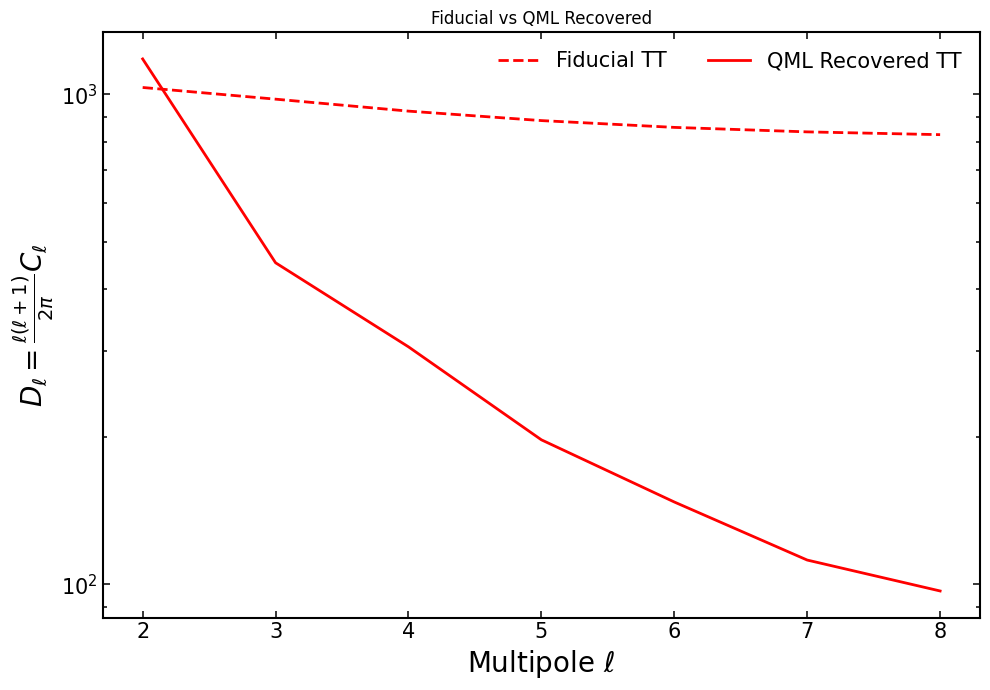

In [15]:
# Validate results and create diagnostic plots
print("=== Validation and Visualization ===")

# Create diagnostic plots
fig, ax = plt.subplots()

# Define colors and labels
colors = ["red", "dodgerblue", "forestgreen", "orange", "purple", "maroon"]
labels = ["TT", "EE", "BB", "TE", "TB", "EB"]

ell = np.arange(2, spectra.params.lmax + 1)
n_ell = len(ell)

# Plot original fiducial spectra (before normalizations and smoothing)
print("=== Plotting Original Fiducial Spectra ===")

# Load the original input spectra from the file used to generate simulations
original_clfid = np.loadtxt(params.inputclfile)
ell = original_clfid[:, 0].astype(int)

# Map original spectrum columns to labels
spectrum_map = {
    "TT": 1,  # Column 1 in original file
    "EE": 2,  # Column 2
    "BB": 3,  # Column 3
    "TE": 4,  # Column 4
    "TB": 5,  # Column 5 (should be zero)
    "EB": 6,  # Column 6 (should be zero)
}

# Plot original fiducial spectra
for ispec, spec_label in enumerate(["TT"]):
    if spec_label in spectrum_map and spectrum_map[spec_label] < original_clfid.shape[1]:
        col_idx = spectrum_map[spec_label]
        # Extract the relevant ell range
        ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
        original_spectrum = original_clfid[ell_mask, col_idx]
        ell_plot = ell[ell_mask]

        ax.plot(
            ell_plot,
            original_spectrum,
            "--",
            color=colors[ispec],
            linewidth=2,
            label=f"Fiducial {spec_label}",
            alpha=1,
        )

# Plot computed spectra for comparison
for ispec, spec_label in enumerate(spectra.collection.spectra_labels):
    start_idx = ispec * n_ell
    end_idx = (ispec + 1) * n_ell

    # Plot computed spectrum (average over simulations)
    computed = power_spectra[:, start_idx:end_idx].mean(axis=0)

    ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
    ell_plot = ell[ell_mask]

    ax.plot(
        ell_plot,
        computed,
        color=colors[ispec],
        label=f"QML Recovered {spec_label}",
        alpha=1,
    )

ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell = \frac{{\ell(\ell+1)}}{{2π}}C_\ell$")
ax.set_title("Fiducial vs QML Recovered")
ax.legend(ncol=2)
ax.set_yscale("log")
plt.show()

In [16]:
# Print comparison statistics
print("\n=== Spectrum Comparison Summary ===")
for ispec, spec_label in enumerate(spectra.collection.spectra_labels):
    start_idx = ispec * n_ell
    end_idx = (ispec + 1) * n_ell
    computed = power_spectra[:, start_idx:end_idx].mean(axis=0)

    if spec_label in spectrum_map and spectrum_map[spec_label] < original_clfid.shape[1]:
        col_idx = spectrum_map[spec_label]
        ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
        original_spectrum = original_clfid[ell_mask, col_idx]

        # Compare at overlapping ell values
        if spec_label in ["TB", "EB"]:
            print(f"{spec_label}: Original spectrum is zero!")
            mean = np.mean(computed)
            std = np.std(computed)

            print(f"{spec_label}: QML mean = {mean:.3f} ± {std:.3f}")
            continue

        ratio_mean = np.mean(computed / original_spectrum)
        ratio_std = np.std(computed / original_spectrum)

        print(f"{spec_label}: QML/Original ratio = {ratio_mean:.3f} ± {ratio_std:.3f}")


=== Spectrum Comparison Summary ===
TT: QML/Original ratio = 0.369 ± 0.336


In [17]:
print("\n=== Running full spectra.run() for final verification ===")
spectra = Spectra(param_file)
spectra.run()
high_lev_power_spectra = spectra.get_power_spectra()


=== Running full spectra.run() for final verification ===
2026-05-15 11:07:20 | spectra      | INFO     | Starting Fisher matrix computation...


2026-05-15 11:07:20 | fisher       | INFO     | Starting Fisher matrix analysis pipeline


2026-05-15 11:07:21 | fisher       | INFO     | --------------------------------------------------------------------------------


2026-05-15 11:07:21 | fisher       | INFO     | Fisher matrix computation completed


2026-05-15 11:07:21 | spectra      | INFO     | Fisher matrix computation completed in 0.39 seconds


=== High-level power spectra ===
High-level power shape: (50, 7)
High-level power first 5 values (sim 0): [1205.66256183  589.72676695  240.44192829  137.53691209  101.94957779]


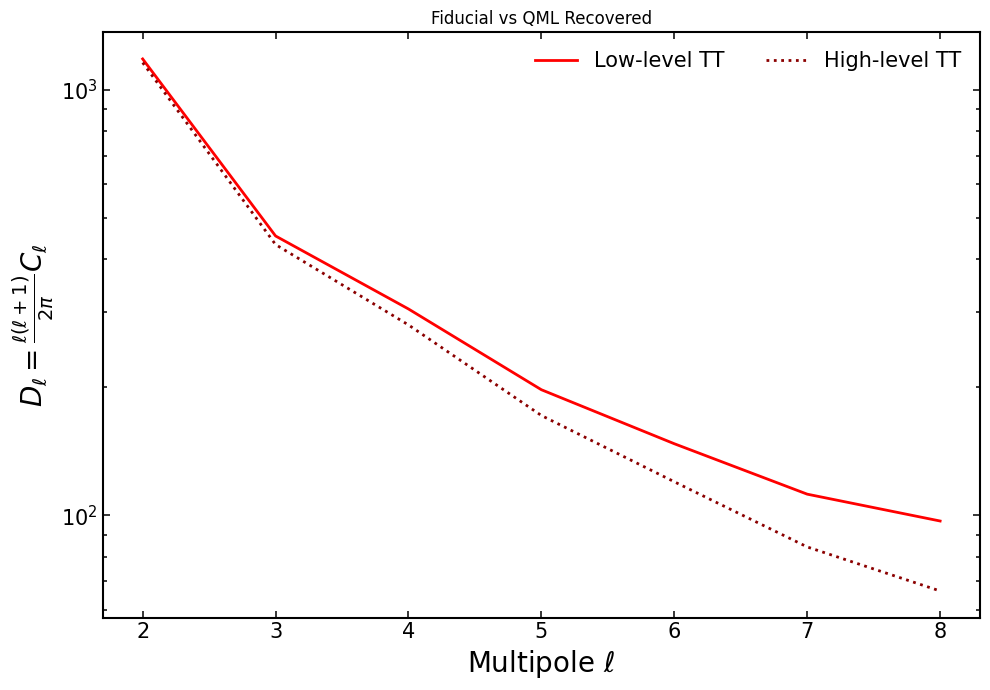

In [18]:
print("=== High-level power spectra ===")
print(f"High-level power shape: {high_lev_power_spectra.shape}")
print(f"High-level power first 5 values (sim 0): {high_lev_power_spectra[0, :5]}")

# Create diagnostic plots
fig, ax = plt.subplots()

# Define colors and labels
colors = ["red", "dodgerblue", "forestgreen", "orange", "magenta", "cyan"]
high_colors = ["darkred", "darkblue", "darkgreen", "darkorange", "purple", "teal"]

# Plot computed spectra for comparison
for ispec, spec_label in enumerate(spectra.collection.spectra_labels):
    start_idx = ispec * n_ell
    end_idx = (ispec + 1) * n_ell

    # Plot computed spectrum (average over simulations)
    computed = power_spectra[:, start_idx:end_idx].mean(axis=0)
    computed_test = high_lev_power_spectra[:, start_idx:end_idx].mean(axis=0)

    ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
    ell_plot = ell[ell_mask]

    ax.plot(
        ell_plot,
        computed,
        color=colors[ispec],
        label=f"Low-level {spec_label}",
        alpha=1,
    )
    ax.plot(
        ell_plot,
        computed_test,
        ":",
        color=high_colors[ispec],
        label=f"High-level {spec_label}",
        alpha=1,
    )

ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell = \frac{{\ell(\ell+1)}}{{2π}}C_\ell$")
ax.set_title("Fiducial vs QML Recovered")
ax.legend(ncol=2)
ax.set_yscale("log")
plt.show()